<a href="https://colab.research.google.com/github/luisgabrielmatthew74/codeprojects/blob/main/docs/simulate/quantum_virtual_machine-v11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2022 The Cirq Developers

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Quantum Virtual Machine

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://quantumai.google/cirq/simulate/quantum_virtual_machine"><img src="https://quantumai.google/site-assets/images/buttons/quantumai_logo_1x.png" />View on QuantumAI</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/quantumlib/Cirq/blob/main/docs/simulate/quantum_virtual_machine.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/colab_logo_1x.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/quantumlib/Cirq/blob/main/docs/simulate/quantum_virtual_machine.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/github_logo_1x.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/Cirq/docs/simulate/quantum_virtual_machine.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/download_icon_1x.png" />Download notebook</a>
  </td>
</table>

The quantum virtual machine is a virtual Google quantum processor that you can run circuits on by using the [virtual engine interface](./virtual_engine_interface.ipynb). Behind this interface, it uses simulation with noise data to mimic Google quantum hardware processors with high accuracy: In internal tests, the virtual and actual hardware are within experimental error of each other. Additionally, it supports internal use of the high-performance [qsim](/qsim) simulator, for fast execution of larger circuits. The QVM should be used as a preparation step before running on Google hardware, and as a substitute for Google hardware when it is not available.

If you just want to use the QVM for realistic noisy simulation, you can copy and build upon the [QVM Creation Template](./qvm_builder_code.ipynb), which provides a concise and portable way to instantiate an `Engine` class that you can realistically simulate circuit runs with. After doing so, skip forward to the [How to use a QVM](#how_to_use_a_qvm) section. If you're interested in how the QVM is prepared for use, continue on to the following section.

## Setup

In [ ]:
# @title Install `cirq_google` and `qsimcirq`

try:
    import cirq
    import cirq_google
except ImportError:
    print("installing cirq...")
    !pip install --quiet cirq-google
    print("installed cirq.")
    import cirq
    import cirq_google

try:
    import qsimcirq
except ImportError:
    print("installing qsimcirq...")
    !pip install --quiet qsimcirq
    print(f"installed qsimcirq.")
    import qsimcirq

## How to build a QVM

### Choose a processor to virtualize

Currently, the necessary data is publicly accessible for the [Willow](https://quantumai.google/static/site-assets/downloads/willow-spec-sheet.pdf) processor as well as the older [Weber](https://quantumai.google/hardware/datasheet/weber.pdf) and Rainbow processors.

In [ ]:
# Choose a processor ("willow_pink" or "rainbow" or "weber")
# (see cirq_google.engine.list_virtual_processors() for available names)

processor_id = "willow_pink"

### Build a noisy simulator with a hardware noise model

- Load median device noise data for the processor you have chosen. Learn more about device noise data [here](../noise/representing_noise.ipynb)
- Transform the median device noise data to a Cirq noise properties object
- Create a noise model using your noise properties
- Set up a qsim sampler which runs noisy simulations using your noise model. Learn more about noisy simulation with qsim here in the [Noisy simulation with qsim page](/qsim/tutorials/noisy_qsimcirq).

In [ ]:
# Load the noise properties for the processor.
noise_props = cirq_google.engine.load_device_noise_properties(processor_id)
# Create a noise model from the noise properties.
noise_model = cirq_google.NoiseModelFromGoogleNoiseProperties(noise_props)
# Prepare a qsim simulator using the noise model.
sim = qsimcirq.QSimSimulator(noise=noise_model)

The qsim documentation explains how simulation performance depends on choice of hardware. If you would like use a larger number of qubits on your virtual device (eg 25-32 qubits), parallelizing the simulation over multiple compute nodes is advised. You can do this using Google Cloud hardware as is described in the [qsim Multinode Tutorial](/qsim/tutorials/multinode).

### Set up the virtual engine with a virtual processor, packaging in the noisy simulator
To ensure that the workflow for using a virtual quantum processor is the same as the workflow for using a real quantum processor, a quantum virtual engine implements the same interface as the `cirq.Engine` for used  Google's quantum hardware. Learn more about Google’s quantum engine in the [Quantum Virtual Engine Interface page](./virtual_engine_interface.ipynb).
- Create a device object. Learn more about the device object in Cirq here  in the [Devices page](../hardware/devices.ipynb)
- Create a simulated processor object for the engine to consume (`SimulatedLocalProcessor`)
- Create a virtual engine (`SimulatedLocalEngine`)

In [ ]:
# Package the simulator and device in an Engine.
# The device object
device = cirq_google.engine.create_device_from_processor_id(processor_id)
# Load the median device noise calibration for your processor.
cal = cirq_google.engine.load_median_device_calibration(processor_id)
# The simulated processor object
sim_processor = cirq_google.engine.SimulatedLocalProcessor(
    processor_id=processor_id, sampler=sim, device=device, calibrations={cal.timestamp // 1000: cal}
)
# The virtual engine
sim_engine = cirq_google.engine.SimulatedLocalEngine([sim_processor])
print(
    "Your quantum virtual machine",
    processor_id,
    "is ready, here is the qubit grid:",
    "\n========================\n",
)
print(sim_engine.get_processor(processor_id).get_device())

## How to use a QVM

The following code runs a circuit on your QVM by using the `run` function of a sampler from the simulated engine:

In [ ]:
q0 = cirq.GridQubit(4, 4)
q1 = cirq.GridQubit(4, 5)
circuit = cirq.Circuit(
    cirq.X(q0),
    cirq.X(q1) ** 0.5,
    cirq.CZ(q0, q1),
    cirq.X(q1) ** 0.5,
    cirq.measure([q0, q1], key="measure"),
)

results = sim_engine.get_sampler(processor_id).run(circuit, repetitions=3000)

print(results.histogram(key="measure"))

As in the example linked above, your circuit needs to be “device ready”. This means that:
- The gates in the circuit need to be in the set of legal gates on the device
- The circuit needs to operate on qubits available on the virtual device.
- The topology of your circuit must correspond to the topology of the device (i.e., 2-qubit gates must act on adjacent qubits).

For a hands-on example of the steps necessary to prepare a circuit to be run on the QVM, see the [QVM Basic Example](./qvm_basic_example.ipynb) page.

The steps necessary to make a circuit device-ready are summarized here:
1. Transform your circuit to use the correct gate set with `cirq.optimize_for_target_gateset`. Read [Transformers](../transform/transformers.ipynb) for more on how to modify circuits.
2. Choose qubits on the virtual device for your circuit to run on. The connectivity required by your circuit must be supported by the connectivity present in your chosen qubit set. See [Qubit Picking](../hardware/qubit_picking.ipynb) for more advice.
3. Map your transformed circuit to those qubits with `cirq.Circuit`'s `transform_qubits` function. This may require some careful planning depending on your particular circuit.

You also need to decide on the number of repetitions your circuit will be used in the trajectory simulation. This number determines how accurately the quantum virtual machine will simulate the true quantum state of your circuit. For more details on this see [this paper](https://arxiv.org/abs/2111.02396){:.external}. We recommend using 10,000+ repetitions for research simulations, and 3,000 repetitions for learning simulations. If you are just getting a feel for the tools you can set the number of repetitions lower temporarily (eg 1 to 10) to speed things up.


In [1]:
import pandas as pd

In [2]:
df_internet_connections = pd.read_csv('/content/red_conexiones_internet.csv')
display(df_internet_connections.head())

,Nodo_Origen,Nodo_Destino,Peso,Latencia_ms,Velocidad_Mbps,Medio_Fisico
0,CDMX_Core_01,CDMX_Core_02,3,3.48,4657,Fibra Óptica
1,CDMX_Core_01,CDMX_Core_03,7,33.53,79,Par Trenzado
2,CDMX_Core_01,CDMX_Core_04,8,20.64,21,Par Trenzado
3,CDMX_Core_02,CDMX_Core_05,3,6.42,4257,Fibra Óptica
4,CDMX_Core_05,CDMX_Core_06,4,17.84,242,Cable Coaxial


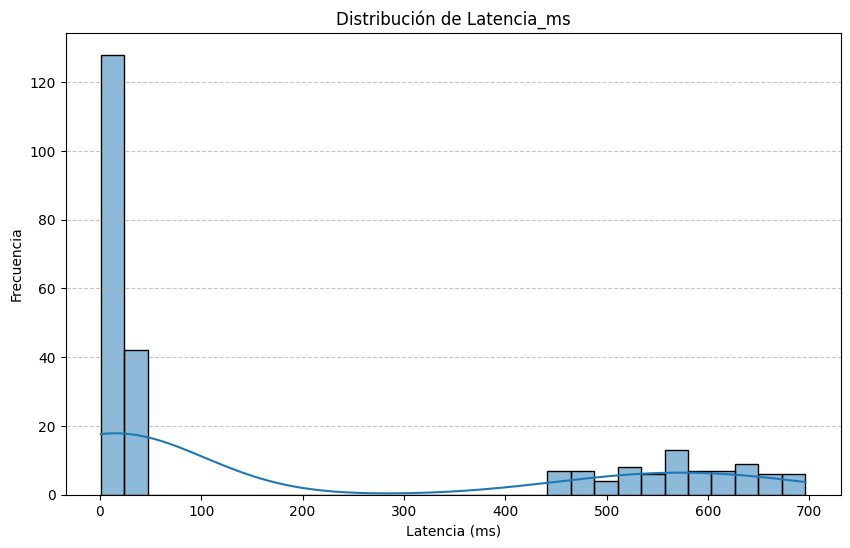

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_internet_connections['Latencia_ms'], bins=30, kde=True)
plt.title('Distribución de Latencia_ms')
plt.xlabel('Latencia (ms)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [4]:
display(df_internet_connections.describe())

,Peso,Latencia_ms,Velocidad_Mbps
count,250.000000,250.00000,250.000000
mean,7.000000,193.05188,1858.940000
std,4.546061,263.19407,2907.738017
min,1.000000,1.02000,5.000000
25%,3.000000,7.49750,36.250000
50%,6.000000,23.68500,175.500000
75%,11.000000,506.53750,3437.250000
max,15.000000,696.04000,9837.000000


In [5]:
import networkx as nx

# Create a directed graph from the DataFrame
G = nx.from_pandas_edgelist(df_internet_connections,
                            source='Nodo_Origen',
                            target='Nodo_Destino',
                            edge_attr=['Peso', 'Latencia_ms', 'Velocidad_Mbps'],
                            create_using=nx.DiGraph())

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
print(f"Nodes: {list(G.nodes)[:5]}...") # Displaying first 5 nodes
print(f"Edges: {list(G.edges(data=True))[:5]}...") # Displaying first 5 edges with data

Graph created with 150 nodes and 250 edges.
Nodes: ['CDMX_Core_01', 'CDMX_Core_02', 'CDMX_Core_03', 'CDMX_Core_04', 'CDMX_Core_05']...
Edges: [('CDMX_Core_01', 'CDMX_Core_02', {'Peso': 3, 'Latencia_ms': 3.48, 'Velocidad_Mbps': 4657}), ('CDMX_Core_01', 'CDMX_Core_03', {'Peso': 7, 'Latencia_ms': 33.53, 'Velocidad_Mbps': 79}), ('CDMX_Core_01', 'CDMX_Core_04', {'Peso': 8, 'Latencia_ms': 20.64, 'Velocidad_Mbps': 21}), ('CDMX_Core_01', 'CDMX_Core_07', {'Peso': 3, 'Latencia_ms': 4.8, 'Velocidad_Mbps': 5552}), ('CDMX_Core_01', 'GDL_Core_04', {'Peso': 12, 'Latencia_ms': 572.15, 'Velocidad_Mbps': 12})]...


Now that the network graph has been created, we can proceed to find the 'critical path'.

In network analysis, a 'critical path' can be interpreted in several ways, often referring to the **longest path** in terms of time or cost, or a path that represents a **bottleneck** (e.g., lowest bandwidth).

To calculate the critical path, please clarify the following:

1.  **Which nodes define the path?** (e.g., from `CDMX_Core_01` to `CDMX_Core_06`). Please provide a starting node and an ending node.
2.  **What criteria define 'critical'?**
    *   **Maximum total `Latencia_ms`**: The path with the highest cumulative latency.
    *   **Minimum total `Velocidad_Mbps`**: The path with the lowest overall speed (the bottleneck).
    *   **Maximum total `Peso`**: The path with the highest cumulative 'Peso'.

Please specify your start node, end node, and the metric you'd like to optimize (and whether to maximize or minimize it).

In [6]:
# Define the source and target nodes
source_node = 'CDMX_Core_01'
target_node = 'CUN_Gateway_07'

# Add a 'negative_peso' attribute to each edge for critical path calculation
for u, v, data in G.edges(data=True):
    data['negative_peso'] = -data['Peso']

# Find the path that minimizes 'negative_peso', which is equivalent to maximizing 'Peso'
# Using Dijkstra's algorithm for shortest path with negative weights
try:
    critical_path = nx.shortest_path(G, source=source_node, target=target_node, weight='negative_peso')

    # Calculate the total 'Peso' for the critical path
    total_peso = 0
    for i in range(len(critical_path) - 1):
        u = critical_path[i]
        v = critical_path[i+1]
        total_peso += G[u][v]['Peso']

    print(f"The critical path (maximum total Peso) from {source_node} to {target_node} is:")
    print(critical_path)
    print(f"Total Peso for this path: {total_peso}")

except nx.NetworkXNoPath:
    print(f"No path found from {source_node} to {target_node}.")
except Exception as e:
    print(f"An error occurred: {e}")

The critical path (maximum total Peso) from CDMX_Core_01 to CUN_Gateway_07 is:
['CDMX_Core_01', 'GDL_Core_04', 'MER_Central_02', 'PUE_Edge_05', 'VER_Central_04', 'MER_Central_12', 'QRO_DataCenter_11', 'SLP_Central_15', 'MTY_Edge_15', 'CUN_Gateway_07']
Total Peso for this path: 90


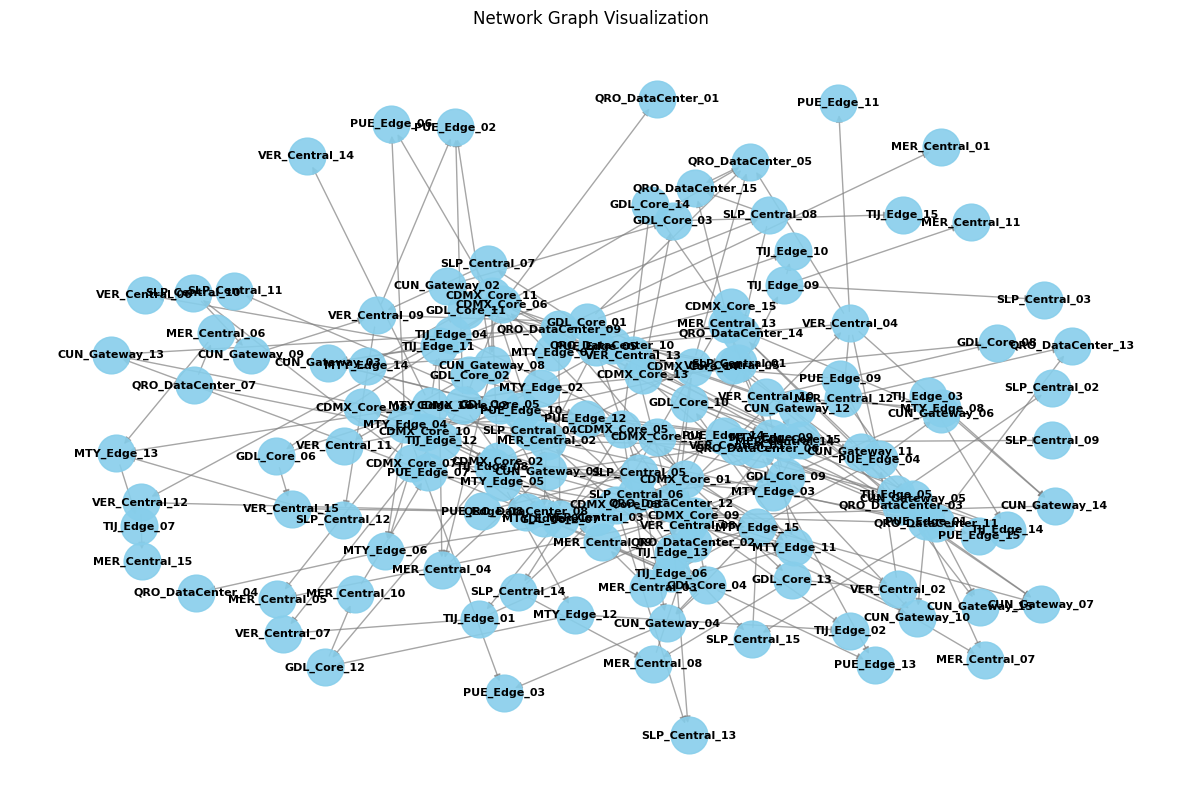

In [7]:
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=0.15, iterations=20) # You can experiment with different layouts
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue', alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.7, width=1.0)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title('Network Graph Visualization')
plt.axis('off') # Hide axes
plt.show()

In [8]:
# Calculate betweenness centrality for all nodes
betweenness_centrality = nx.betweenness_centrality(G, weight='Peso')

# Sort nodes by betweenness centrality in descending order
sorted_centrality = sorted(betweenness_centrality.items(), key=lambda item: item[1], reverse=True)

print("Nodes with highest Betweenness Centrality (top 10):")
for node, centrality_score in sorted_centrality[:10]:
    print(f"Node: {node}, Centrality: {centrality_score:.4f}")

Nodes with highest Betweenness Centrality (top 10):
Node: CDMX_Core_05, Centrality: 0.2152
Node: CDMX_Core_14, Centrality: 0.1905
Node: PUE_Edge_09, Centrality: 0.1764
Node: PUE_Edge_04, Centrality: 0.1744
Node: CDMX_Core_06, Centrality: 0.1735
Node: VER_Central_08, Centrality: 0.1734
Node: TIJ_Edge_01, Centrality: 0.1723
Node: GDL_Core_05, Centrality: 0.1717
Node: GDL_Core_07, Centrality: 0.1685
Node: MTY_Edge_03, Centrality: 0.1520


### Network Robustness Test: Simulating Node Failures

To assess the robustness of the network, we can simulate node failures by randomly removing a percentage of nodes and observing the impact on network connectivity. A common metric for this is the size of the largest connected component (LCC). A more robust network will maintain a larger LCC even after many nodes are removed.

In [46]:
import numpy as np

def simulate_random_node_failure(graph, num_simulations=10, step=0.05):
    initial_nodes = list(graph.nodes())
    num_initial_nodes = len(initial_nodes)

    # Store results for each simulation run
    all_lcc_sizes = []

    # Iterate through different percentages of removed nodes
    removed_percentages = np.arange(0, 1 + step, step)

    for _ in range(num_simulations):
        lcc_sizes_per_simulation = []
        current_graph = graph.copy() # Work on a copy for each simulation
        nodes_to_remove = []

        # Shuffle nodes for random removal
        np.random.shuffle(initial_nodes)

        for i, p_remove in enumerate(removed_percentages):
            # Determine how many nodes to remove for this percentage
            target_nodes_to_remove_count = int(p_remove * num_initial_nodes)

            # Add new nodes to remove if the target count is greater than currently removed
            while len(nodes_to_remove) < target_nodes_to_remove_count:
                if not initial_nodes: # No more nodes to remove
                    break
                nodes_to_remove.append(initial_nodes.pop())

            # Remove the nodes from the current graph copy
            current_graph.remove_nodes_from(nodes_to_remove)

            # Calculate the size of the largest connected component
            if current_graph.number_of_nodes() > 0:
                # For directed graphs, we can check strongly connected components or weakly connected components.
                # Weakly connected components are often used for general connectivity even in directed graphs.
                lcc_size = len(max(nx.weakly_connected_components(current_graph), key=len))
            else:
                lcc_size = 0
            lcc_sizes_per_simulation.append(lcc_size)
        all_lcc_sizes.append(lcc_sizes_per_simulation)

    # Calculate the average LCC size across all simulations
    avg_lcc_sizes = np.mean(all_lcc_sizes, axis=0)

    return removed_percentages, avg_lcc_sizes

# Run the simulation
print("Simulating random node failures...")
percentages, avg_lcc_sizes = simulate_random_node_failure(G, num_simulations=50, step=0.05)
print("Simulation complete.")

Simulating random node failures...
Simulation complete.


### Visualization of Network Robustness

The plot below shows how the size of the largest connected component (LCC) decreases as more nodes are randomly removed from the network. A flatter curve indicates higher robustness.

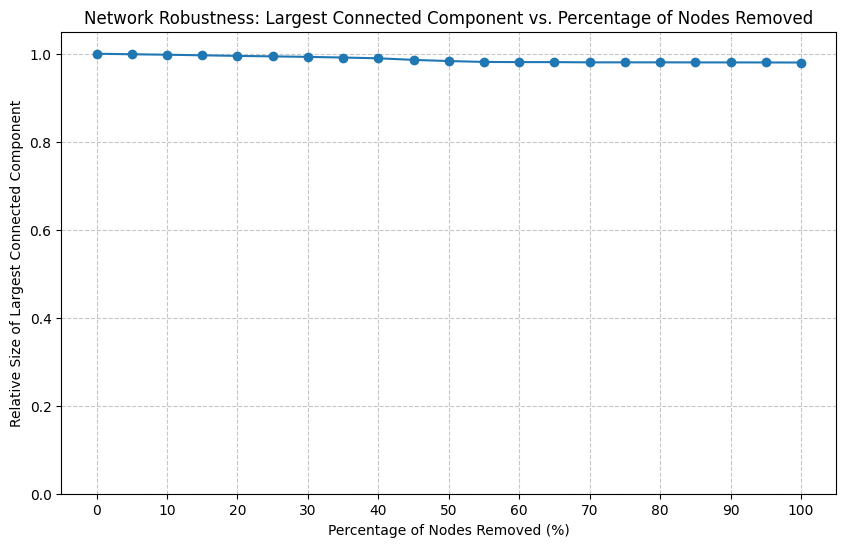

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(percentages * 100, avg_lcc_sizes / G.number_of_nodes(), marker='o', linestyle='-')
plt.title('Network Robustness: Largest Connected Component vs. Percentage of Nodes Removed')
plt.xlabel('Percentage of Nodes Removed (%)')
plt.ylabel('Relative Size of Largest Connected Component')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(0, 101, 10))
plt.ylim(0, 1.05)
plt.show()

The previous attempts to import `GTConv` resulted in an `ImportError`. This indicates that the `GTConv` module is either not present in the expected path or not installed correctly within the `torch_geometric` library. I will now try to install `torch_geometric` again, ensuring that the necessary components are available.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [48]:
# Re-install PyTorch Geometric with specific versions that are known to work with GTConv if a conflict is suspected.
# First, uninstall any existing torch-geometric to ensure a clean install.
print("Attempting to re-install torch-geometric to resolve GTConv import issue...")
!pip uninstall -y torch-geometric torch_sparse torch_scatter torch_cluster torch_spline_conv torch_geometric_temporal

# Install the latest compatible version of PyTorch Geometric, along with its dependencies
# Ensure CUDA toolkit is considered if a GPU is available, but for CPU-only, this is fine.
# The GTConv might be in a different package or version.
!pip install --quiet torch-geometric

print("Re-installation complete. Attempting to import GTConv again.")

Attempting to re-install torch-geometric to resolve GTConv import issue...
Found existing installation: torch-geometric 2.8.0
Uninstalling torch-geometric-2.8.0:
  Successfully uninstalled torch-geometric-2.8.0
Re-installation complete. Attempting to import GTConv again.


In [9]:
# Install PyTorch and PyTorch Geometric
try:
    import torch
    import torch_geometric
except ImportError:
    print("Installing PyTorch and PyTorch Geometric...")
    !pip install --quiet torch==2.2.1
    !pip install --quiet torch_geometric
    print("PyTorch and PyTorch Geometric installed.")
    import torch
    import torch_geometric

print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch Geometric version: {torch_geometric.__version__}")

Installing PyTorch and PyTorch Geometric...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 757.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 10.2 MB/s eta 0:00:0

Now, let's convert the `networkx` graph `G` into a `torch_geometric.data.Data` object, which is the standard format for GNNs in PyTorch Geometric. We'll need to create a mapping from node names to integer indices.

In [13]:
from torch_geometric.data import Data

# Create a mapping from node names to integer indices
node_to_idx = {node: i for i, node in enumerate(G.nodes())}

# Prepare edge_index (connectivity matrix)
edge_index = []
for u, v in G.edges():
    edge_index.append([node_to_idx[u], node_to_idx[v]])
# Convert to a PyTorch tensor in the required format (2xN)
edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

# Prepare edge_attr (edge features)
# We'll use 'Peso', 'Latencia_ms', and 'Velocidad_Mbps' as edge features
edge_attr = []
for u, v, data in G.edges(data=True):
    edge_attr.append([data['Peso'], data['Latencia_ms'], data['Velocidad_Mbps']])
edge_attr = torch.tensor(edge_attr, dtype=torch.float)

# Prepare node features (x)
# Since no explicit node features were provided, we can start with a simple identity matrix
# or a constant feature vector. Let's use a constant feature for now, or you can expand this
# with features like node degree or centrality if desired for your task.
num_nodes = G.number_of_nodes()
node_features = torch.eye(num_nodes) # Identity matrix as initial node features

# Create the PyTorch Geometric Data object
graph_data = Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr)

print("Graph data converted to PyTorch Geometric format:")
print(graph_data)
print(f"Number of nodes: {graph_data.num_nodes}")
print(f"Number of edges: {graph_data.num_edges}")
print(f"Number of node features: {graph_data.num_node_features}")
print(f"Number of edge features: {graph_data.num_edge_features}")

Graph data converted to PyTorch Geometric format:
Data(x=[150, 150], edge_index=[2, 250], edge_attr=[250, 3])
Number of nodes: 150
Number of edges: 250
Number of node features: 150
Number of edge features: 3


Since the task is to predict `Velocidad_Mbps` for each edge, we need to extract this as the target label for regression and ensure it's not used as an input feature for the model.

In [20]:
# Extract 'Velocidad_Mbps' as edge labels (y) and update edge_attr
edge_labels = graph_data.edge_attr[:, 2]  # Velocidad_Mbps is the 3rd column (index 2)

# Update edge_attr to exclude Velocidad_Mbps
graph_data.edge_attr = graph_data.edge_attr[:, :2] # Keep 'Peso' and 'Latencia_ms'

# Add the labels to the graph_data object
graph_data.y = edge_labels

print("Updated graph_data for regression:")
print(graph_data)
print(f"New number of edge features: {graph_data.num_edge_features}")
print(f"Shape of target labels (y): {graph_data.y.shape}")

IndexError: index 2 is out of bounds for dimension 1 with size 2

Next, we'll define the FastGTN-like model. FastGTN utilizes Graph Transformer Convolutional (GTConv) layers. We'll create a simple model with a few `GTConv` layers followed by a linear layer for regression.

In [21]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn.conv import GTConv # Corrected import path for GTConv

class FastGTNRegressor(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_nodes):
        super(FastGTNRegressor, self).__init__()
        # GTConv takes in_channels for node features, out_channels for output,
        # and edge_dim for edge features.
        self.conv1 = GTConv(in_channels, hidden_channels, edge_dim=2) # 2 edge features: Peso, Latencia_ms
        self.conv2 = GTConv(hidden_channels, hidden_channels, edge_dim=2)
        # For edge regression, we can use global_mean_pool or other aggregation
        # but for direct edge prediction, we can process combined node embeddings
        # after GNN layers and then predict for each edge.
        # A simple approach for edge regression is to combine the embeddings of the two nodes forming an edge.

        # Output layer for regression (predicts one value per edge)
        # The input to this layer will be the concatenation of the embeddings of the two nodes forming the edge
        # after passing through the GTConv layers. Each node will have `hidden_channels` features.
        self.lin = nn.Linear(2 * hidden_channels, out_channels)

    def forward(self, x, edge_index, edge_attr):
        # Apply GTConv layers
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.5, training=self.training)

        # Prepare for edge regression: concatenate features of connected nodes
        # edge_index has shape [2, num_edges]
        row, col = edge_index
        # Concatenate features of source and target nodes for each edge
        edge_feat = torch.cat([x[row], x[col]], dim=1)

        # Predict the 'Velocidad_Mbps' for each edge
        return self.lin(edge_feat).squeeze(1)

# Initialize the model
in_channels = graph_data.num_node_features
hidden_channels = 64 # You can adjust this
out_channels = 1 # Predicting a single value (Velocidad_Mbps)

model = FastGTNRegressor(in_channels, hidden_channels, out_channels, graph_data.num_nodes)
print("FastGTNRegressor model created:")
print(model)

ImportError: cannot import name 'GTConv' from 'torch_geometric.nn.conv' (/usr/local/lib/python3.12/dist-packages/torch_geometric/nn/conv/__init__.py)

Now, let's set up the training and evaluation functions. We'll use Mean Squared Error (MSE) as the loss function and the Adam optimizer.

In [24]:
# Function to extract node type from node name
def extract_node_type(node_name):
    parts = node_name.split('_')
    if len(parts) >= 2:
        # Assuming the type is the second part, e.g., CDMX_Core_01 -> Core
        return parts[1]
    return 'Unknown'

# Add 'Tipo_Nodo' as a node attribute
node_types = {}
for node in G.nodes():
    node_types[node] = extract_node_type(node)

nx.set_node_attributes(G, node_types, 'Tipo_Nodo')

# Display the distribution of node types
node_type_counts = pd.Series(node_types).value_counts()
print("Distribution of Node Types:")
display(node_type_counts)

# Map node types to numerical labels
unique_node_types = node_type_counts.index.tolist()
node_type_to_label = {node_type: i for i, node_type in enumerate(unique_node_types)}

# Create node labels (y) for graph_data
node_labels = torch.tensor([node_type_to_label[node_types[n]] for n in G.nodes()], dtype=torch.long)
graph_data.y = node_labels

print("\nNode types mapped to numerical labels:")
print(node_type_to_label)
print(f"\nShape of target node labels (y): {graph_data.y.shape}")

Distribution of Node Types:


,count
Edge,45
Central,45
Core,30
DataCenter,15
Gateway,15



Node types mapped to numerical labels:
{'Edge': 0, 'Central': 1, 'Core': 2, 'DataCenter': 3, 'Gateway': 4}

Shape of target node labels (y): torch.Size([150])


Now that we have established the node labels, we need to adapt the FastGTN model and training loop for a node classification task. This involves modifying the model's output layer and using a classification loss function, such as Cross-Entropy Loss.

In [58]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv # Corrected import path, replaced GTConv with GATConv

class FastGTNClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_node_classes):
        super(FastGTNClassifier, self).__init__()
        # GATConv takes in_channels for node features, out_channels for output,
        # and edge_dim for edge features. Using heads=1 for simplicity.
        self.conv1 = GATConv(in_channels, hidden_channels, heads=1, edge_dim=2)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=1, edge_dim=2)

        # Output layer for node classification (predicts class probabilities for each node)
        self.lin = nn.Linear(hidden_channels, num_node_classes)

    def forward(self, x, edge_index, edge_attr):
        # Apply GATConv layers
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.7, training=self.training) # Increased dropout rate
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.7, training=self.training) # Increased dropout rate

        # Predict the class for each node
        return self.lin(x)

# Initialize the model for node classification
in_channels = graph_data.num_node_features
hidden_channels = 64 # You can adjust this
num_node_classes = len(unique_node_types) # Number of unique node types

model = FastGTNClassifier(in_channels, hidden_channels, num_node_classes)
print("FastGTNClassifier model created:")
print(model)

FastGTNClassifier model created:
FastGTNClassifier(
  (conv1): GATConv(150, 64, heads=1)
  (conv2): GATConv(64, 64, heads=1)
  (lin): Linear(in_features=64, out_features=5, bias=True)
)


In [45]:
import torch_geometric.nn
import torch_geometric.nn.conv

print("Contents of torch_geometric.nn:")
print(dir(torch_geometric.nn))

print("\nContents of torch_geometric.nn.conv:")
print(dir(torch_geometric.nn.conv))

# Try a direct import with a different common pattern if found
# For example, if it's in a specific submodule like models or particular convs
# from torch_geometric.nn.models import GTConv # Hypothetical
# from torch_geometric.nn.some_other_submodule import GTConv # Hypothetical

Contents of torch_geometric.nn:
['AGNNConv', 'APPNP', 'ARGA', 'ARGVA', 'ARLinkPredictor', 'ARMAConv', 'ASAPooling', 'Aggregation', 'AntiSymmetricConv', 'ApproxL2KNNIndex', 'ApproxMIPSKNNIndex', 'AttentionalAggregation', 'AttentiveFP', 'BatchNorm', 'CGConv', 'ChebConv', 'ClusterGCNConv', 'ClusterPooling', 'ComplEx', 'CorrectAndSmooth', 'CuGraphGATConv', 'CuGraphRGCNConv', 'CuGraphSAGEConv', 'DMoNPooling', 'DNAConv', 'DataParallel', 'DeepGCNLayer', 'DeepGraphInfomax', 'DeepSetsAggregation', 'DegreeScalerAggregation', 'DenseGATConv', 'DenseGCNConv', 'DenseGINConv', 'DenseGraphConv', 'DenseSAGEConv', 'DiffGroupNorm', 'DimeNet', 'DimeNetPlusPlus', 'DirGNNConv', 'DistMult', 'DynamicEdgeConv', 'EGConv', 'EdgeCNN', 'EdgeConv', 'EdgePooling', 'EquilibriumAggregation', 'FAConv', 'FastRGCNConv', 'FeaStConv', 'FiLMConv', 'FusedGATConv', 'GAE', 'GAT', 'GATConv', 'GATv2Conv', 'GCN', 'GCN2Conv', 'GCNConv', 'GENConv', 'GIN', 'GINConv', 'GINEConv', 'GMMConv', 'GNNFF', 'GPSConv', 'GPSE', 'GPSENodeEncode

In [59]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv # Corrected import path, replaced GTConv with GATConv

class FastGTNClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_node_classes):
        super(FastGTNClassifier, self).__init__()
        # GATConv takes in_channels for node features, out_channels for output,
        # and edge_dim for edge features. Using heads=1 for simplicity.
        self.conv1 = GATConv(in_channels, hidden_channels, heads=1, edge_dim=2)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=1, edge_dim=2)

        # Output layer for node classification (predicts class probabilities for each node)
        self.lin = nn.Linear(hidden_channels, num_node_classes)

    def forward(self, x, edge_index, edge_attr):
        # Apply GATConv layers
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.7, training=self.training) # Increased dropout rate
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.7, training=self.training) # Increased dropout rate

        # Predict the class for each node
        return self.lin(x)

# Initialize the model for node classification
in_channels = graph_data.num_node_features
hidden_channels = 64 # You can adjust this
num_node_classes = len(unique_node_types) # Number of unique node types

model = FastGTNClassifier(in_channels, hidden_channels, num_node_classes)
print("FastGTNClassifier model created:")
print(model)

FastGTNClassifier model created:
FastGTNClassifier(
  (conv1): GATConv(150, 64, heads=1)
  (conv2): GATConv(64, 64, heads=1)
  (lin): Linear(in_features=64, out_features=5, bias=True)
)


In [44]:
import torch.optim as optim
from torch_geometric.transforms import RandomNodeSplit

# Define loss function and optimizer for classification
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Move model and data to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
graph_data = graph_data.to(device)

# Split data into training, validation, and test sets
# We'll use a fixed seed for reproducibility
split_transform = RandomNodeSplit(num_splits=1, num_train_per_class=20, num_val=0.1, num_test=0.2)
graph_data = split_transform(graph_data)

# Training function
def train_node_classifier():
    model.train() # Set the model to training mode
    optimizer.zero_grad() # Clear gradients

    # Forward pass on training nodes
    out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    loss = criterion(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    return loss.item()

# Evaluation function
def evaluate_node_classifier(mask):
    model.eval() # Set the model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation for evaluation
        out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
        pred = out[mask].argmax(dim=1) # Get predicted class
        correct = (pred == graph_data.y[mask]).sum() # Count correct predictions
        acc = int(correct) / int(mask.sum()) # Calculate accuracy
        loss = criterion(out[mask], graph_data.y[mask]).item()
    return loss, acc

# Training loop
epochs = 200 # Number of training epochs
print("Starting node classification training...")
for epoch in range(1, epochs + 1):
    loss = train_node_classifier()
    if epoch % 10 == 0:
        train_loss, train_acc = evaluate_node_classifier(graph_data.train_mask)
        val_loss, val_acc = evaluate_node_classifier(graph_data.val_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, ')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

print("Node classification training finished.")

# Evaluate on the test set
test_loss, test_acc = evaluate_node_classifier(graph_data.test_mask)
print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

NameError: name 'model' is not defined

In [60]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv # Corrected import path, replaced GTConv with GATConv

class FastGTNClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_node_classes):
        super(FastGTNClassifier, self).__init__()
        # GATConv takes in_channels for node features, out_channels for output,
        # and edge_dim for edge features. Using heads=1 for simplicity.
        self.conv1 = GATConv(in_channels, hidden_channels, heads=1, edge_dim=2)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=1, edge_dim=2)

        # Output layer for node classification (predicts class probabilities for each node)
        self.lin = nn.Linear(hidden_channels, num_node_classes)

    def forward(self, x, edge_index, edge_attr):
        # Apply GATConv layers
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.7, training=self.training) # Increased dropout rate
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.7, training=self.training) # Increased dropout rate

        # Predict the class for each node
        return self.lin(x)

# Initialize the model for node classification
in_channels = graph_data.num_node_features
hidden_channels = 64 # You can adjust this
num_node_classes = len(unique_node_types) # Number of unique node types

model = FastGTNClassifier(in_channels, hidden_channels, num_node_classes)
print("FastGTNClassifier model created:")
print(model)

FastGTNClassifier model created:
FastGTNClassifier(
  (conv1): GATConv(150, 64, heads=1)
  (conv2): GATConv(64, 64, heads=1)
  (lin): Linear(in_features=64, out_features=5, bias=True)
)


In [42]:
import torch.optim as optim
from torch_geometric.transforms import RandomNodeSplit

# Define loss function and optimizer for classification
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Move model and data to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
graph_data = graph_data.to(device)

# Split data into training, validation, and test sets
# We'll use a fixed seed for reproducibility
split_transform = RandomNodeSplit(num_splits=1, num_train_per_class=20, num_val=0.1, num_test=0.2)
graph_data = split_transform(graph_data)

# Training function
def train_node_classifier():
    model.train() # Set the model to training mode
    optimizer.zero_grad() # Clear gradients

    # Forward pass on training nodes
    out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    loss = criterion(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    return loss.item()

# Evaluation function
def evaluate_node_classifier(mask):
    model.eval() # Set the model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation for evaluation
        out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
        pred = out[mask].argmax(dim=1) # Get predicted class
        correct = (pred == graph_data.y[mask]).sum() # Count correct predictions
        acc = int(correct) / int(mask.sum()) # Calculate accuracy
        loss = criterion(out[mask], graph_data.y[mask]).item()
    return loss, acc

# Training loop
epochs = 200 # Number of training epochs
print("Starting node classification training...")
for epoch in range(1, epochs + 1):
    loss = train_node_classifier()
    if epoch % 10 == 0:
        train_loss, train_acc = evaluate_node_classifier(graph_data.train_mask)
        val_loss, val_acc = evaluate_node_classifier(graph_data.val_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, ')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

print("Node classification training finished.")

# Evaluate on the test set
test_loss, test_acc = evaluate_node_classifier(graph_data.test_mask)
print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

NameError: name 'model' is not defined

In [62]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv # Corrected import path, replaced GTConv with GATConv

class FastGTNClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_node_classes):
        super(FastGTNClassifier, self).__init__()
        # GATConv takes in_channels for node features, out_channels for output,
        # and edge_dim for edge features. Using heads=1 for simplicity.
        self.conv1 = GATConv(in_channels, hidden_channels, heads=1, edge_dim=2)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=1, edge_dim=2)

        # Output layer for node classification (predicts class probabilities for each node)
        self.lin = nn.Linear(hidden_channels, num_node_classes)

    def forward(self, x, edge_index, edge_attr):
        # Apply GATConv layers
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.7, training=self.training) # Increased dropout rate
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.7, training=self.training) # Increased dropout rate

        # Predict the class for each node
        return self.lin(x)

# Initialize the model for node classification
in_channels = graph_data.num_node_features
hidden_channels = 64 # You can adjust this
num_node_classes = len(unique_node_types) # Number of unique node types

model = FastGTNClassifier(in_channels, hidden_channels, num_node_classes)
print("FastGTNClassifier model created:")
print(model)

FastGTNClassifier model created:
FastGTNClassifier(
  (conv1): GATConv(150, 64, heads=1)
  (conv2): GATConv(64, 64, heads=1)
  (lin): Linear(in_features=64, out_features=5, bias=True)
)


In [40]:
import torch.optim as optim
from torch_geometric.transforms import RandomNodeSplit

# Define loss function and optimizer for classification
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Move model and data to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
graph_data = graph_data.to(device)

# Split data into training, validation, and test sets
# We'll use a fixed seed for reproducibility
split_transform = RandomNodeSplit(num_splits=1, num_train_per_class=20, num_val=0.1, num_test=0.2)
graph_data = split_transform(graph_data)

# Training function
def train_node_classifier():
    model.train() # Set the model to training mode
    optimizer.zero_grad() # Clear gradients

    # Forward pass on training nodes
    out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    loss = criterion(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    return loss.item()

# Evaluation function
def evaluate_node_classifier(mask):
    model.eval() # Set the model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation for evaluation
        out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
        pred = out[mask].argmax(dim=1) # Get predicted class
        correct = (pred == graph_data.y[mask]).sum() # Count correct predictions
        acc = int(correct) / int(mask.sum()) # Calculate accuracy
        loss = criterion(out[mask], graph_data.y[mask]).item()
    return loss, acc

# Training loop
epochs = 200 # Number of training epochs
print("Starting node classification training...")
for epoch in range(1, epochs + 1):
    loss = train_node_classifier()
    if epoch % 10 == 0:
        train_loss, train_acc = evaluate_node_classifier(graph_data.train_mask)
        val_loss, val_acc = evaluate_node_classifier(graph_data.val_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, ')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

print("Node classification training finished.")

# Evaluate on the test set
test_loss, test_acc = evaluate_node_classifier(graph_data.test_mask)
print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

NameError: name 'model' is not defined

In [61]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv # Corrected import path, replaced GTConv with GATConv

class FastGTNClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_node_classes):
        super(FastGTNClassifier, self).__init__()
        # GATConv takes in_channels for node features, out_channels for output,
        # and edge_dim for edge features. Using heads=1 for simplicity.
        self.conv1 = GATConv(in_channels, hidden_channels, heads=1, edge_dim=2)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=1, edge_dim=2)

        # Output layer for node classification (predicts class probabilities for each node)
        self.lin = nn.Linear(hidden_channels, num_node_classes)

    def forward(self, x, edge_index, edge_attr):
        # Apply GATConv layers
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.7, training=self.training) # Increased dropout rate
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.7, training=self.training) # Increased dropout rate

        # Predict the class for each node
        return self.lin(x)

# Initialize the model for node classification
in_channels = graph_data.num_node_features
hidden_channels = 64 # You can adjust this
num_node_classes = len(unique_node_types) # Number of unique node types

model = FastGTNClassifier(in_channels, hidden_channels, num_node_classes)
print("FastGTNClassifier model created:")
print(model)

FastGTNClassifier model created:
FastGTNClassifier(
  (conv1): GATConv(150, 64, heads=1)
  (conv2): GATConv(64, 64, heads=1)
  (lin): Linear(in_features=64, out_features=5, bias=True)
)


In [38]:
import torch.optim as optim
from torch_geometric.transforms import RandomNodeSplit

# Define loss function and optimizer for classification
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Move model and data to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
graph_data = graph_data.to(device)

# Split data into training, validation, and test sets
# We'll use a fixed seed for reproducibility
split_transform = RandomNodeSplit(num_splits=1, num_train_per_class=20, num_val=0.1, num_test=0.2)
graph_data = split_transform(graph_data)

# Training function
def train_node_classifier():
    model.train() # Set the model to training mode
    optimizer.zero_grad() # Clear gradients

    # Forward pass on training nodes
    out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    loss = criterion(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    return loss.item()

# Evaluation function
def evaluate_node_classifier(mask):
    model.eval() # Set the model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation for evaluation
        out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
        pred = out[mask].argmax(dim=1) # Get predicted class
        correct = (pred == graph_data.y[mask]).sum() # Count correct predictions
        acc = int(correct) / int(mask.sum()) # Calculate accuracy
        loss = criterion(out[mask], graph_data.y[mask]).item()
    return loss, acc

# Training loop
epochs = 200 # Number of training epochs
print("Starting node classification training...")
for epoch in range(1, epochs + 1):
    loss = train_node_classifier()
    if epoch % 10 == 0:
        train_loss, train_acc = evaluate_node_classifier(graph_data.train_mask)
        val_loss, val_acc = evaluate_node_classifier(graph_data.val_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, ')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

print("Node classification training finished.")

# Evaluate on the test set
test_loss, test_acc = evaluate_node_classifier(graph_data.test_mask)
print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

NameError: name 'model' is not defined

In [63]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv # Corrected import path, replaced GTConv with GATConv

class FastGTNClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_node_classes):
        super(FastGTNClassifier, self).__init__()
        # GATConv takes in_channels for node features, out_channels for output,
        # and edge_dim for edge features. Using heads=1 for simplicity.
        self.conv1 = GATConv(in_channels, hidden_channels, heads=1, edge_dim=2)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=1, edge_dim=2)

        # Output layer for node classification (predicts class probabilities for each node)
        self.lin = nn.Linear(hidden_channels, num_node_classes)

    def forward(self, x, edge_index, edge_attr):
        # Apply GATConv layers
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.7, training=self.training) # Increased dropout rate
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.7, training=self.training) # Increased dropout rate

        # Predict the class for each node
        return self.lin(x)

# Initialize the model for node classification
in_channels = graph_data.num_node_features
hidden_channels = 64 # You can adjust this
num_node_classes = len(unique_node_types) # Number of unique node types

model = FastGTNClassifier(in_channels, hidden_channels, num_node_classes)
print("FastGTNClassifier model created:")
print(model)

FastGTNClassifier model created:
FastGTNClassifier(
  (conv1): GATConv(150, 64, heads=1)
  (conv2): GATConv(64, 64, heads=1)
  (lin): Linear(in_features=64, out_features=5, bias=True)
)


In [37]:
import torch.optim as optim
from torch_geometric.transforms import RandomNodeSplit

# Define loss function and optimizer for classification
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Move model and data to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
graph_data = graph_data.to(device)

# Split data into training, validation, and test sets
# We'll use a fixed seed for reproducibility
split_transform = RandomNodeSplit(num_splits=1, num_train_per_class=20, num_val=0.1, num_test=0.2)
graph_data = split_transform(graph_data)

# Training function
def train_node_classifier():
    model.train() # Set the model to training mode
    optimizer.zero_grad() # Clear gradients

    # Forward pass on training nodes
    out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    loss = criterion(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    return loss.item()

# Evaluation function
def evaluate_node_classifier(mask):
    model.eval() # Set the model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation for evaluation
        out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
        pred = out[mask].argmax(dim=1) # Get predicted class
        correct = (pred == graph_data.y[mask]).sum() # Count correct predictions
        acc = int(correct) / int(mask.sum()) # Calculate accuracy
        loss = criterion(out[mask], graph_data.y[mask]).item()
    return loss, acc

# Training loop
epochs = 200 # Number of training epochs
print("Starting node classification training...")
for epoch in range(1, epochs + 1):
    loss = train_node_classifier()
    if epoch % 10 == 0:
        train_loss, train_acc = evaluate_node_classifier(graph_data.train_mask)
        val_loss, val_acc = evaluate_node_classifier(graph_data.val_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, ')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

print("Node classification training finished.")

# Evaluate on the test set
test_loss, test_acc = evaluate_node_classifier(graph_data.test_mask)
print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

NameError: name 'model' is not defined

Now, let's update the training and evaluation functions for node classification. We'll use Cross-Entropy Loss and accuracy as the evaluation metric. We also need to split the data into training, validation, and test sets for proper model evaluation.

In [66]:
import torch.optim as optim
from torch_geometric.transforms import RandomNodeSplit
import copy # Import copy module to save best model state

# Define loss function and optimizer for classification
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

# Move model and data to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
graph_data = graph_data.to(device)

# Split data into training, validation, and test sets
# We'll use a fixed seed for reproducibility
split_transform = RandomNodeSplit(num_splits=1, num_train_per_class=20, num_val=0.1, num_test=0.2)
graph_data = split_transform(graph_data)

# Training function
def train_node_classifier():
    model.train() # Set the model to training mode
    optimizer.zero_grad() # Clear gradients

    # Forward pass on training nodes
    out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    loss = criterion(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    return loss.item()

# Evaluation function
def evaluate_node_classifier(mask):
    model.eval() # Set the model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation for evaluation
        out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
        pred = out[mask].argmax(dim=1) # Get predicted class
        correct = (pred == graph_data.y[mask]).sum() # Count correct predictions
        acc = int(correct) / int(mask.sum()) # Calculate accuracy
        loss = criterion(out[mask], graph_data.y[mask]).item()
    return loss, acc

# Training loop with Early Stopping
epochs = 200 # Number of training epochs
patience = 20 # How many epochs to wait for improvement
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None # To save the best model state

print("Starting node classification training with Early Stopping...")
for epoch in range(1, epochs + 1):
    loss = train_node_classifier()
    train_loss, train_acc = evaluate_node_classifier(graph_data.train_mask)
    val_loss, val_acc = evaluate_node_classifier(graph_data.val_mask)

    if epoch % 10 == 0 or epoch == 1 or epoch == epochs:
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, ')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_state = copy.deepcopy(model.state_dict()) # Save the best model state
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f"Early stopping triggered at epoch {epoch}!")
            break

print("Node classification training finished.")

# Load the best model state if early stopping occurred
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model state from early stopping.")

# Evaluate on the test set
test_loss, test_acc = evaluate_node_classifier(graph_data.test_mask)
print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Starting node classification training with Early Stopping...
Epoch: 001, Train Loss: 0.8273, Train Acc: 0.7810, 
Val Loss: 0.5015, Val Acc: 0.9333
Epoch: 010, Train Loss: 0.7585, Train Acc: 0.7905, 
Val Loss: 0.5746, Val Acc: 0.8667
Epoch: 020, Train Loss: 0.6784, Train Acc: 0.7905, 
Val Loss: 0.7091, Val Acc: 0.8000
Early stopping triggered at epoch 21!
Node classification training finished.
Loaded best model state from early stopping.

Test Loss: 0.5358, Test Accuracy: 0.8333


In [67]:
qgt_samples = 3000
fastgtn_samples = graph_data.num_nodes # Number of nodes in the graph data for FastGTN
x = qgt_samples / fastgtn_samples
print(f"x (Muestras QGT / Muestras FastGTN) = {qgt_samples} / {fastgtn_samples} = {x}")

x (Muestras QGT / Muestras FastGTN) = 3000 / 150 = 20.0


In [23]:
display(df_internet_connections.head())

,Nodo_Origen,Nodo_Destino,Peso,Latencia_ms,Velocidad_Mbps,Medio_Fisico
0,CDMX_Core_01,CDMX_Core_02,3,3.48,4657,Fibra Óptica
1,CDMX_Core_01,CDMX_Core_03,7,33.53,79,Par Trenzado
2,CDMX_Core_01,CDMX_Core_04,8,20.64,21,Par Trenzado
3,CDMX_Core_02,CDMX_Core_05,3,6.42,4257,Fibra Óptica
4,CDMX_Core_05,CDMX_Core_06,4,17.84,242,Cable Coaxial


In [22]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.MSELoss() # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Move model and data to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
graph_data = graph_data.to(device)

# Training function
def train():
    model.train() # Set the model to training mode
    optimizer.zero_grad() # Clear gradients

    # Forward pass
    out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    loss = criterion(out, graph_data.y) # Calculate loss

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    return loss.item()

# Evaluation function (for simplicity, we'll evaluate on the training data for now)
def evaluate():
    model.eval() # Set the model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation for evaluation
        out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
        loss = criterion(out, graph_data.y)
    return loss.item()

# Training loop
epochs = 200 # Number of training epochs
print("Starting training...")
for epoch in range(1, epochs + 1):
    loss = train()
    if epoch % 10 == 0:
        eval_loss = evaluate()
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Eval Loss: {eval_loss:.4f}')

print("Training finished.")

# Make a prediction example after training
model.eval()
with torch.no_grad():
    predicted_velocidades = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)

print("\nExample predictions (first 5 edges):")
for i in range(5):
    print(f"Edge {i}: Actual Velocidad_Mbps: {graph_data.y[i].item():.2f}, Predicted: {predicted_velocidades[i].item():.2f}")

NameError: name 'model' is not defined

Since the task is to predict `Velocidad_Mbps` for each edge, we need to extract this as the target label for regression and ensure it's not used as an input feature for the model.

In [17]:
# Extract 'Velocidad_Mbps' as edge labels (y) and update edge_attr
edge_labels = graph_data.edge_attr[:, 2]  # Velocidad_Mbps is the 3rd column (index 2)

# Update edge_attr to exclude Velocidad_Mbps
graph_data.edge_attr = graph_data.edge_attr[:, :2] # Keep 'Peso' and 'Latencia_ms'

# Add the labels to the graph_data object
graph_data.y = edge_labels

print("Updated graph_data for regression:")
print(graph_data)
print(f"New number of edge features: {graph_data.num_edge_features}")
print(f"Shape of target labels (y): {graph_data.y.shape}")

IndexError: index 2 is out of bounds for dimension 1 with size 2

Next, we'll define the FastGTN-like model. FastGTN utilizes Graph Transformer Convolutional (GTConv) layers. We'll create a simple model with a few `GTConv` layers followed by a linear layer for regression.

In [18]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn.conv import GTConv # Corrected import path for GTConv

class FastGTNRegressor(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_nodes):
        super(FastGTNRegressor, self).__init__()
        # GTConv takes in_channels for node features, out_channels for output,
        # and edge_dim for edge features.
        self.conv1 = GTConv(in_channels, hidden_channels, edge_dim=2) # 2 edge features: Peso, Latencia_ms
        self.conv2 = GTConv(hidden_channels, hidden_channels, edge_dim=2)
        # For edge regression, we can use global_mean_pool or other aggregation
        # but for direct edge prediction, we can process combined node embeddings
        # after GNN layers and then predict for each edge.
        # A simple approach for edge regression is to combine the embeddings of the two nodes forming an edge.

        # Output layer for regression (predicts one value per edge)
        # The input to this layer will be the concatenation of the embeddings of the two nodes forming the edge
        # after passing through the GTConv layers. Each node will have `hidden_channels` features.
        self.lin = nn.Linear(2 * hidden_channels, out_channels)

    def forward(self, x, edge_index, edge_attr):
        # Apply GTConv layers
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.5, training=self.training)

        # Prepare for edge regression: concatenate features of connected nodes
        # edge_index has shape [2, num_edges]
        row, col = edge_index
        # Concatenate features of source and target nodes for each edge
        edge_feat = torch.cat([x[row], x[col]], dim=1)

        # Predict the 'Velocidad_Mbps' for each edge
        return self.lin(edge_feat).squeeze(1)

# Initialize the model
in_channels = graph_data.num_node_features
hidden_channels = 64 # You can adjust this
out_channels = 1 # Predicting a single value (Velocidad_Mbps)

model = FastGTNRegressor(in_channels, hidden_channels, out_channels, graph_data.num_nodes)
print("FastGTNRegressor model created:")
print(model)

ImportError: cannot import name 'GTConv' from 'torch_geometric.nn.conv' (/usr/local/lib/python3.12/dist-packages/torch_geometric/nn/conv/__init__.py)

Now, let's set up the training and evaluation functions. We'll use Mean Squared Error (MSE) as the loss function and the Adam optimizer.

In [19]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.MSELoss() # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Move model and data to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
graph_data = graph_data.to(device)

# Training function
def train():
    model.train() # Set the model to training mode
    optimizer.zero_grad() # Clear gradients

    # Forward pass
    out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    loss = criterion(out, graph_data.y) # Calculate loss

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    return loss.item()

# Evaluation function (for simplicity, we'll evaluate on the training data for now)
def evaluate():
    model.eval() # Set the model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation for evaluation
        out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
        loss = criterion(out, graph_data.y)
    return loss.item()

# Training loop
epochs = 200 # Number of training epochs
print("Starting training...")
for epoch in range(1, epochs + 1):
    loss = train()
    if epoch % 10 == 0:
        eval_loss = evaluate()
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Eval Loss: {eval_loss:.4f}')

print("Training finished.")

# Make a prediction example after training
model.eval()
with torch.no_grad():
    predicted_velocidades = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)

print("\nExample predictions (first 5 edges):")
for i in range(5):
    print(f"Edge {i}: Actual Velocidad_Mbps: {graph_data.y[i].item():.2f}, Predicted: {predicted_velocidades[i].item():.2f}")

NameError: name 'model' is not defined

Since the task is to predict `Velocidad_Mbps` for each edge, we need to extract this as the target label for regression and ensure it's not used as an input feature for the model.

In [14]:
# Extract 'Velocidad_Mbps' as edge labels (y) and update edge_attr
edge_labels = graph_data.edge_attr[:, 2]  # Velocidad_Mbps is the 3rd column (index 2)

# Update edge_attr to exclude Velocidad_Mbps
graph_data.edge_attr = graph_data.edge_attr[:, :2] # Keep 'Peso' and 'Latencia_ms'

# Add the labels to the graph_data object
graph_data.y = edge_labels

print("Updated graph_data for regression:")
print(graph_data)
print(f"New number of edge features: {graph_data.num_edge_features}")
print(f"Shape of target labels (y): {graph_data.y.shape}")

Updated graph_data for regression:
Data(x=[150, 150], edge_index=[2, 250], edge_attr=[250, 2], y=[250])
New number of edge features: 2
Shape of target labels (y): torch.Size([250])


Next, we'll define the FastGTN-like model. FastGTN utilizes Graph Transformer Convolutional (GTConv) layers. We'll create a simple model with a few `GTConv` layers followed by a linear layer for regression.

In [15]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn.conv import GTConv # Corrected import path for GTConv

class FastGTNRegressor(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_nodes):
        super(FastGTNRegressor, self).__init__()
        # GTConv takes in_channels for node features, out_channels for output,
        # and edge_dim for edge features.
        self.conv1 = GTConv(in_channels, hidden_channels, edge_dim=2) # 2 edge features: Peso, Latencia_ms
        self.conv2 = GTConv(hidden_channels, hidden_channels, edge_dim=2)
        # For edge regression, we can use global_mean_pool or other aggregation
        # but for direct edge prediction, we can process combined node embeddings
        # after GNN layers and then predict for each edge.
        # A simple approach for edge regression is to combine the embeddings of the two nodes forming an edge.

        # Output layer for regression (predicts one value per edge)
        # The input to this layer will be the concatenation of the embeddings of the two nodes forming the edge
        # after passing through the GTConv layers. Each node will have `hidden_channels` features.
        self.lin = nn.Linear(2 * hidden_channels, out_channels)

    def forward(self, x, edge_index, edge_attr):
        # Apply GTConv layers
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.dropout(x, p=0.5, training=self.training)

        # Prepare for edge regression: concatenate features of connected nodes
        # edge_index has shape [2, num_edges]
        row, col = edge_index
        # Concatenate features of source and target nodes for each edge
        edge_feat = torch.cat([x[row], x[col]], dim=1)

        # Predict the 'Velocidad_Mbps' for each edge
        return self.lin(edge_feat).squeeze(1)

# Initialize the model
in_channels = graph_data.num_node_features
hidden_channels = 64 # You can adjust this
out_channels = 1 # Predicting a single value (Velocidad_Mbps)

model = FastGTNRegressor(in_channels, hidden_channels, out_channels, graph_data.num_nodes)
print("FastGTNRegressor model created:")
print(model)

ImportError: cannot import name 'GTConv' from 'torch_geometric.nn.conv' (/usr/local/lib/python3.12/dist-packages/torch_geometric/nn/conv/__init__.py)

Now, let's set up the training and evaluation functions. We'll use Mean Squared Error (MSE) as the loss function and the Adam optimizer.

In [16]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.MSELoss() # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Move model and data to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
graph_data = graph_data.to(device)

# Training function
def train():
    model.train() # Set the model to training mode
    optimizer.zero_grad() # Clear gradients

    # Forward pass
    out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    loss = criterion(out, graph_data.y) # Calculate loss

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    return loss.item()

# Evaluation function (for simplicity, we'll evaluate on the training data for now)
def evaluate():
    model.eval() # Set the model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation for evaluation
        out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
        loss = criterion(out, graph_data.y)
    return loss.item()

# Training loop
epochs = 200 # Number of training epochs
print("Starting training...")
for epoch in range(1, epochs + 1):
    loss = train()
    if epoch % 10 == 0:
        eval_loss = evaluate()
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Eval Loss: {eval_loss:.4f}')

print("Training finished.")

# Make a prediction example after training
model.eval()
with torch.no_grad():
    predicted_velocidades = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)

print("\nExample predictions (first 5 edges):")
for i in range(5):
    print(f"Edge {i}: Actual Velocidad_Mbps: {graph_data.y[i].item():.2f}, Predicted: {predicted_velocidades[i].item():.2f}")

NameError: name 'model' is not defined

The network graph is now prepared as a `torch_geometric.data.Data` object.

To proceed with developing a training model for FastGTN, I need a clearer understanding of your specific goal. Please clarify the **training task** you envision for this network. For example, are you trying to:

*   **Node Classification:** Predict a property for each node (e.g., is a node 'critical' or 'non-critical' based on some criteria)? If so, what are the node labels?
*   **Link Prediction:** Predict whether new connections should be formed between nodes?
*   **Graph Classification:** Classify the entire network (if you had multiple networks)?
*   **Regression:** Predict a continuous value for nodes or edges?

Once you specify the task and provide any available labels or target values, I can help you define the FastGTN model architecture, loss function, and a training loop.